## SGM Disparity Estimation Pipeline

Load → Preprocess → SGM → Post-process → Depth

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from pathlib import Path

# %matplotlib inline
# plt.rcParams['figure.dpi'] = 100

In [2]:
#  CONFIG： modify here
RECTIFIED_PATH  = Path(r'd:\FAU\Kurse\Masterarbeit\2_methods\dataset\dataset_1_rectified')
OUTPUT_PATH     = Path(r'd:\FAU\Kurse\Masterarbeit\2_methods\dataset\dataset_1_sgm')
SUBMISSION_PATH = Path(r'd:\FAU\Kurse\Masterarbeit\2_methods\submissions\sgm_submission')
DATASET_NAME    = 'dataset_1'
KEYFRAME        = 'keyframe_2'

### Step 1: Load Rectified Images

In [3]:
rect_dir = RECTIFIED_PATH / KEYFRAME / 'rectified'

img_left  = cv2.imread(str(rect_dir / 'Left_Image_rectified.png'))
img_right = cv2.imread(str(rect_dir / 'Right_Image_rectified.png'))
Q = np.load(str(rect_dir / 'Q_matrix.npy'))

print(f'Image: {img_left.shape[1]}x{img_left.shape[0]}')
print(f'Q[2,3] (focal): {Q[2,3]:.1f}, Q[3,2] (1/baseline): {Q[3,2]:.4f}')

Image: 1280x1024
Q[2,3] (focal): 1120.4, Q[3,2] (1/baseline): 0.2413


### Step 2: Preprocess (Grayscale + CLAHE)

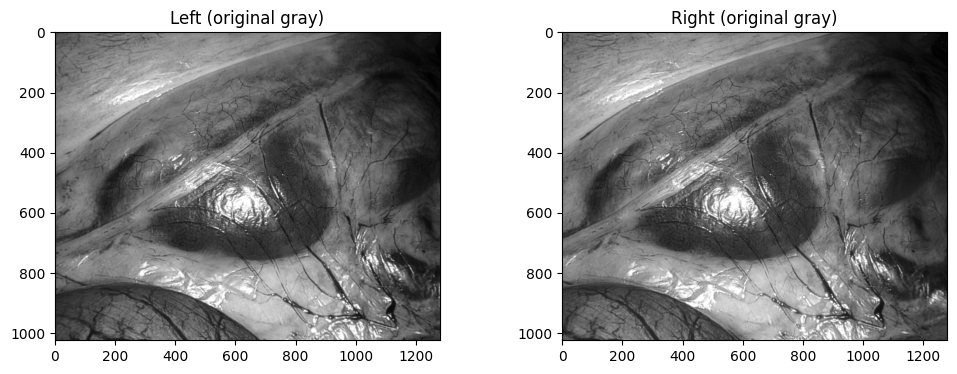

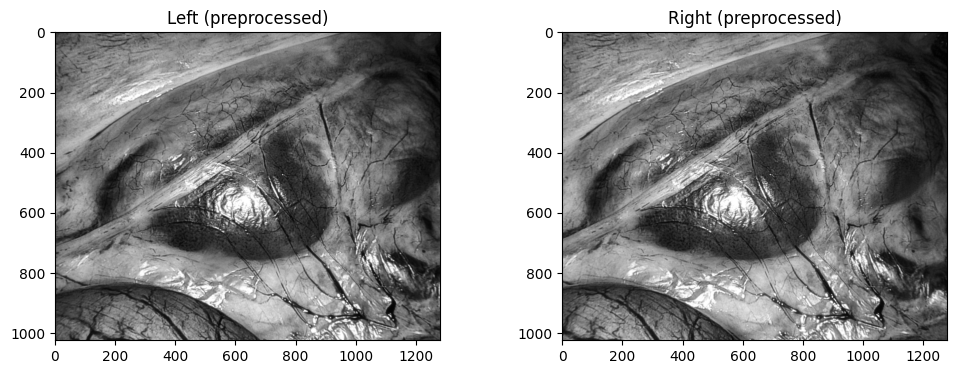

In [4]:
# Convert to grayscale
gray_left  = cv2.cvtColor(img_left,  cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

fig_raw, ax_raw = plt.subplots(1, 2, figsize=(12, 4))
ax_raw[0].imshow(gray_left, cmap='gray')
ax_raw[0].set_title('Left (original gray)')
ax_raw[1].imshow(gray_right, cmap='gray')
ax_raw[1].set_title('Right (original gray)')
plt.show()

# CLAHE contrast enhancement (optional)
USE_CLAHE = True
if USE_CLAHE:
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
    gray_left  = clahe.apply(gray_left)
    gray_right = clahe.apply(gray_right)

# Visualization of preprocessed images
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(gray_left, cmap='gray')
ax[0].set_title('Left (preprocessed)')
ax[1].imshow(gray_right, cmap='gray')
ax[1].set_title('Right (preprocessed)')
plt.show()

### Step 3: SGM Disparity Estimation

In [5]:
#  SGM Parameters - Adjustable
# return disparity map (not displayed here)

num_disp   = 128      # Disparity search range (must be multiple of 16)
block_size = 3        # Matching window size (odd number)

# Smoothness penalties
P1 = 8 * 3 * block_size ** 2    # Small change penalty (3: number of image channels)
P2 = 32 * 3 * block_size ** 2   # Large change penalty

# Create SGBM matcher
# only include cost and aggregation, no Left-Right Consistency Check and postprocessing(filtering)
sgbm = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=P1,
    P2=P2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=2,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

# Compute disparity (raw output is int16, divide by 16 for actual pixel values)
disp_raw = sgbm.compute(gray_left, gray_right)
disp = disp_raw.astype(np.float32) / 16.0

# Mark invalid pixels as NaN
disp[disp < 0] = np.nan

print(f'Disparity range: [{np.nanmin(disp):.1f}, {np.nanmax(disp):.1f}] px')
print(f'Valid pixels: {np.sum(~np.isnan(disp))} / {disp.size} ({np.mean(~np.isnan(disp))*100:.1f}%)')

Disparity range: [33.3, 123.0] px
Valid pixels: 1170714 / 1310720 (89.3%)


### Step 4: Post-processing (WLS Filter)

After WLS: Valid pixels 90.0%


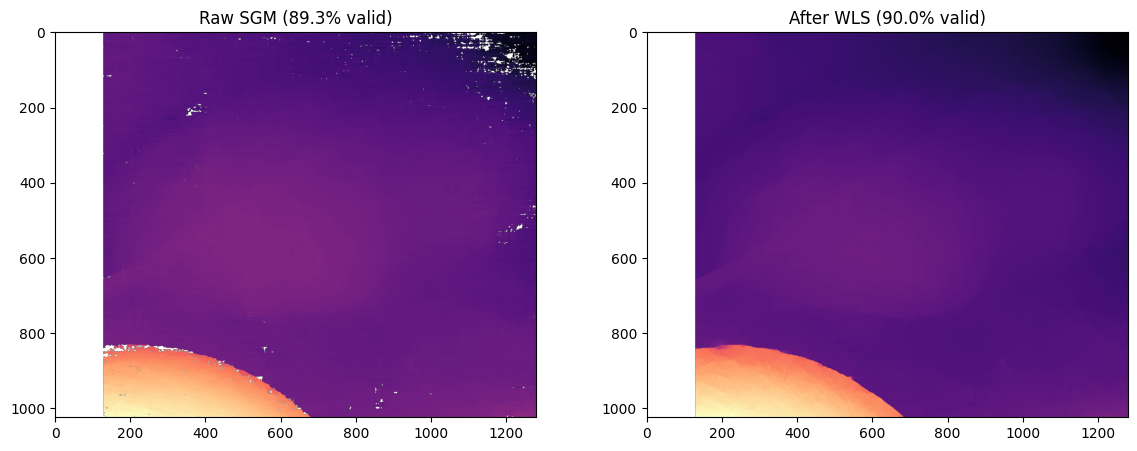

In [6]:
# WLS Filter: Left-right consistency check + edge-preserving smoothing
# Requires opencv-contrib-python

# Compute right disparity map
right_matcher = cv2.ximgproc.createRightMatcher(sgbm)
disp_left_raw  = sgbm.compute(gray_left, gray_right)
disp_right_raw = right_matcher.compute(gray_right, gray_left)

# WLS filtering
wls = cv2.ximgproc.createDisparityWLSFilter(sgbm)
wls.setLambda(8000)      # Smoothing strength
wls.setSigmaColor(1.5)   # Edge sensitivity

disp_filtered_raw = wls.filter(disp_left_raw, gray_left, disparity_map_right=disp_right_raw)
disp_filtered = disp_filtered_raw.astype(np.float32) / 16.0
disp_filtered[disp_filtered < 0] = np.nan

print(f'After WLS: Valid pixels {np.mean(~np.isnan(disp_filtered))*100:.1f}%')

# Compare raw vs WLS
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(disp, cmap='magma')
# ax[0].imshow(disp, cmap='gray')
ax[0].set_title(f'Raw SGM ({np.mean(~np.isnan(disp))*100:.1f}% valid)')
ax[1].imshow(disp_filtered, cmap='magma')
# ax[1].imshow(disp_filtered, cmap='gray')
ax[1].set_title(f'After WLS ({np.mean(~np.isnan(disp_filtered))*100:.1f}% valid)')
plt.show()

# Use filtered result
# disp = disp_filtered

#### 4a: Median Filter (on WLS result)

After WLS + Median (k=5): Valid pixels 90.0%


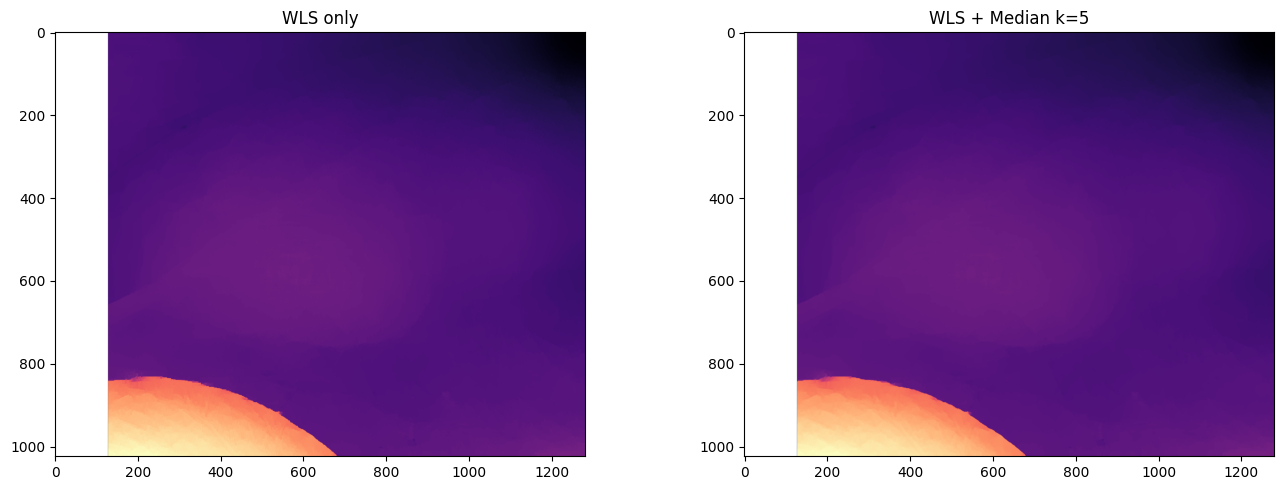

In [7]:
# Median Filter: removes salt-and-pepper noise / isolated outliers
MEDIAN_KSIZE = 5  # kernel size (odd number: 3, 5, 7)

disp_median = disp_filtered.copy()
nan_mask = np.isnan(disp_median)
disp_median[nan_mask] = 0
disp_median = cv2.medianBlur(disp_median.astype(np.float32), MEDIAN_KSIZE)
disp_median[nan_mask] = np.nan

print(f'After WLS + Median (k={MEDIAN_KSIZE}): Valid pixels {np.mean(~np.isnan(disp_median))*100:.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(disp_filtered, cmap='magma')
ax[0].set_title('WLS only')
ax[1].imshow(disp_median, cmap='magma')
ax[1].set_title(f'WLS + Median k={MEDIAN_KSIZE}')
plt.tight_layout()
plt.show()

#### 4b: Bilateral Filter (on WLS result)

After WLS + Bilateral (d=7): Valid pixels 90.0%


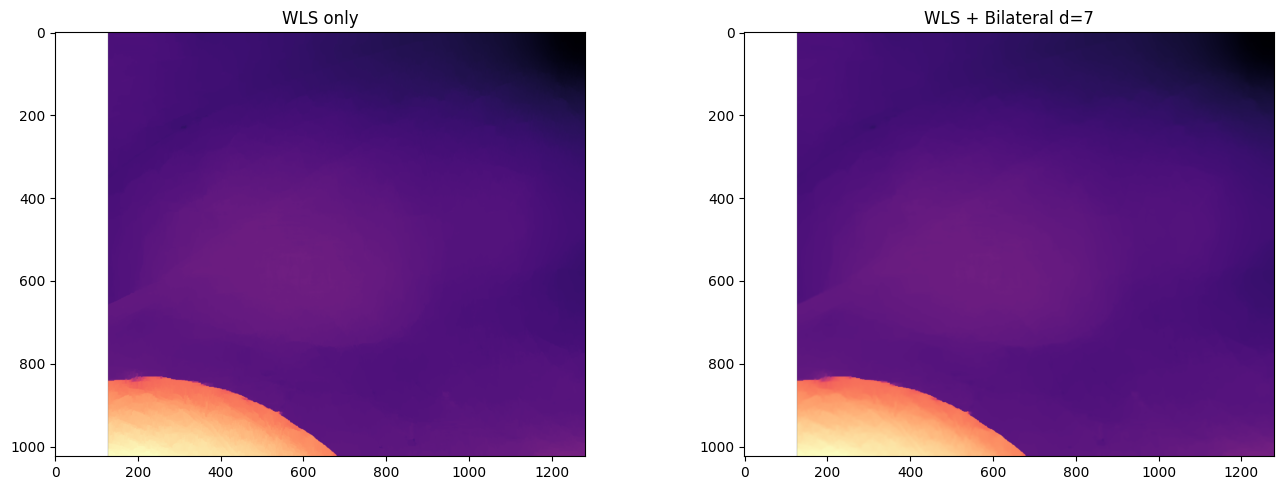

In [8]:
# Bilateral Filter: edge-preserving smoothing, better at keeping tissue boundaries
BILATERAL_D = 7           # neighborhood diameter
BILATERAL_SIGMA_C = 10    # color/intensity sigma
BILATERAL_SIGMA_S = 10    # spatial sigma

disp_bilateral = disp_filtered.copy()
nan_mask_b = np.isnan(disp_bilateral)
disp_bilateral[nan_mask_b] = 0
disp_bilateral = cv2.bilateralFilter(
    disp_bilateral.astype(np.float32),
    d=BILATERAL_D, sigmaColor=BILATERAL_SIGMA_C, sigmaSpace=BILATERAL_SIGMA_S
)
disp_bilateral[nan_mask_b] = np.nan

print(f'After WLS + Bilateral (d={BILATERAL_D}): Valid pixels {np.mean(~np.isnan(disp_bilateral))*100:.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(disp_filtered, cmap='magma')
ax[0].set_title('WLS only')
ax[1].imshow(disp_bilateral, cmap='magma')
ax[1].set_title(f'WLS + Bilateral d={BILATERAL_D}')
plt.tight_layout()
plt.show()

#### 4c: Compare All & Select

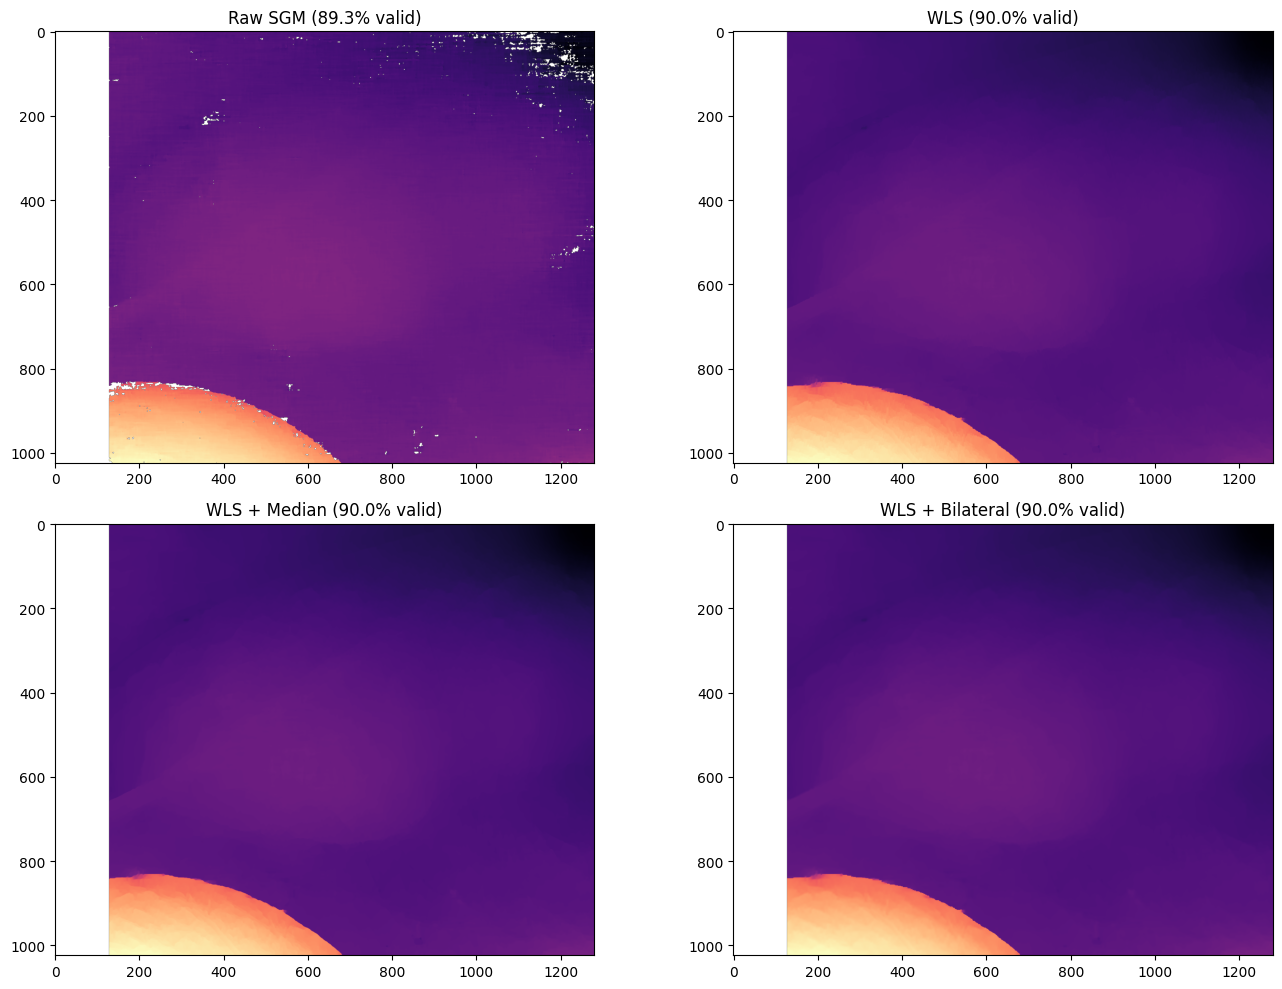

Selected for depth: WLS + wls


In [9]:
# Compare: Raw SGM vs WLS vs WLS+Median vs WLS+Bilateral
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax[0,0].imshow(disp, cmap='magma')
ax[0,0].set_title(f'Raw SGM ({np.mean(~np.isnan(disp))*100:.1f}% valid)')
ax[0,1].imshow(disp_filtered, cmap='magma')
ax[0,1].set_title(f'WLS ({np.mean(~np.isnan(disp_filtered))*100:.1f}% valid)')
ax[1,0].imshow(disp_median, cmap='magma')
ax[1,0].set_title(f'WLS + Median ({np.mean(~np.isnan(disp_median))*100:.1f}% valid)')
ax[1,1].imshow(disp_bilateral, cmap='magma')
ax[1,1].set_title(f'WLS + Bilateral ({np.mean(~np.isnan(disp_bilateral))*100:.1f}% valid)')
plt.tight_layout()
plt.show()

# Select one post-processing to use for downstream depth conversion
POST_MODE = 'wls'  # Options: 'wls', 'median', 'bilateral'

if POST_MODE == 'median':
    disp = disp_median
elif POST_MODE == 'bilateral':
    disp = disp_bilateral
else:
    disp = disp_filtered
print(f'Selected for depth: WLS + {POST_MODE}')

### Step 5: Disparity → Depth

Depth range: [38.0, 117.2] mm


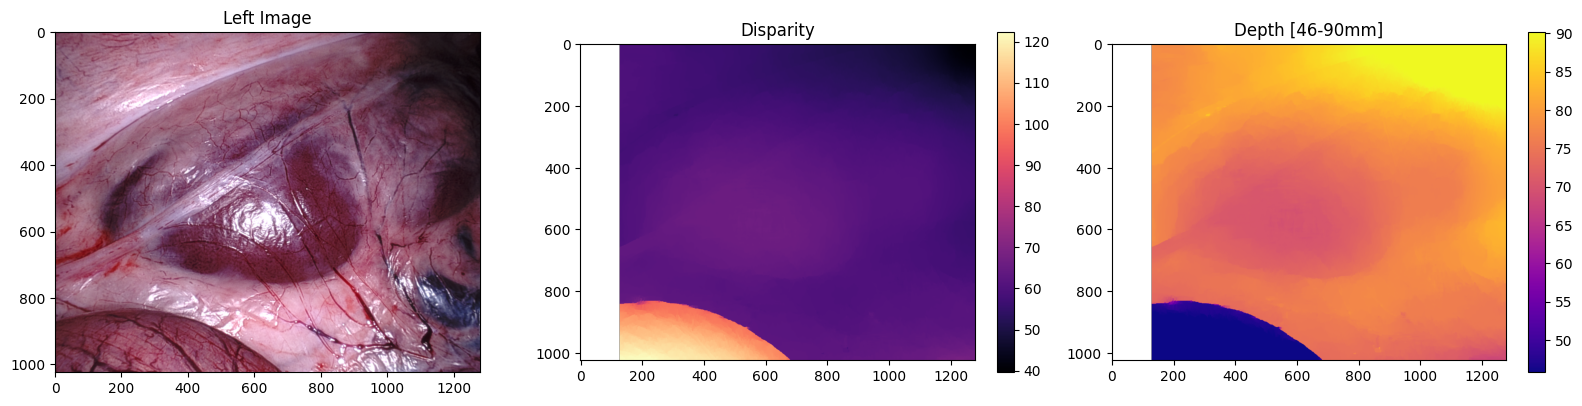

In [10]:
# Convert disparity to 3D point cloud using Q matrix
disp_for_reproject = disp.copy()
disp_for_reproject[np.isnan(disp_for_reproject)] = 0

points_3d = cv2.reprojectImageTo3D(disp_for_reproject, Q, handleMissingValues=True)
depth_map = points_3d[:, :, 2]      # extract Z coordinate as depth

# Mark invalid regions
invalid = np.isnan(disp) | (disp <= 0)
depth_map[invalid] = np.nan

print(f'Depth range: [{np.nanmin(depth_map):.1f}, {np.nanmax(depth_map):.1f}] mm')

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB))
ax[0].set_title('Left Image')
im1 = ax[1].imshow(disp, cmap='magma')
ax[1].set_title('Disparity')
plt.colorbar(im1, ax=ax[1], fraction=0.046)
p5, p95 = np.nanpercentile(depth_map, [5, 95])
im2 = ax[2].imshow(np.clip(depth_map, p5, p95), cmap='plasma')
ax[2].set_title(f'Depth [{p5:.0f}-{p95:.0f}mm]')
plt.colorbar(im2, ax=ax[2], fraction=0.046)
plt.tight_layout()
plt.show()

### Save Results

In [11]:
# Save .npy (for internal reuse) 
out_dir = OUTPUT_PATH / KEYFRAME
out_dir.mkdir(parents=True, exist_ok=True)

np.save(out_dir / 'disparity.npy', disp)
np.save(out_dir / 'depth_map.npy', depth_map)
np.save(out_dir / 'points_3d.npy', points_3d)
print(f'NPY saved to {out_dir}')

# Save .tiff in submission structure (single-channel depth Z)
# Format: submissions/sgm_submission/dataset_1/keyframe_X/frame1.tiff
sub_dir = SUBMISSION_PATH / DATASET_NAME / KEYFRAME
sub_dir.mkdir(parents=True, exist_ok=True)

depth_tiff = depth_map.astype(np.float32).copy()
depth_tiff[np.isnan(depth_tiff) | (depth_tiff <= 0)] = 0

tifffile.imwrite(str(sub_dir / 'frame1.tiff'), depth_tiff)
print(f'TIFF saved to {sub_dir / "frame1.tiff"}')

NPY saved to d:\FAU\Kurse\Masterarbeit\2_methods\dataset\dataset_1_sgm\keyframe_2
TIFF saved to d:\FAU\Kurse\Masterarbeit\2_methods\submissions\sgm_submission\dataset_1\keyframe_2\frame1.tiff


In [ ]:
# Interactive 3D point cloud with Open3D
import open3d as o3d

pts = points_3d.reshape(-1, 3)
valid = np.isfinite(pts).all(axis=1) & (pts[:, 2] > 0)
pts = pts[valid]

# Color by depth (Z) using plasma colormap
z = pts[:, 2]
z_norm = (z - z.min()) / (z.max() - z.min() + 1e-8)
colors = plt.cm.plasma(z_norm)[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts)
pcd.colors = o3d.utility.Vector3dVector(colors)

o3d.visualization.draw_geometries(
    [pcd], window_name='SGM Point Cloud',
    width=1024, height=768, point_show_normal=False
)

In [ ]:
# # Load and visualize saved results
# disp_loaded = np.load(out_dir / 'disparity.npy')
# depth_loaded = np.load(out_dir / 'depth_map.npy')
# points_3d_loaded = np.load(out_dir / 'points_3d.npy')

# plt.imshow(disp_loaded, cmap='magma')  
# plt.colorbar()
# plt.title('Disparity Map')
# plt.show()

### Evaluate with Ground Truth

In [ ]:
import tifffile

DATASET_PATH = Path(r'd:\FAU\Kurse\Masterarbeit\2_methods\dataset\dataset_1')
gt_path = DATASET_PATH / KEYFRAME / 'left_depth_map.tiff'

if gt_path.exists():
    gt_points = tifffile.imread(str(gt_path)).astype(np.float32)
    gt_depth = gt_points[:, :, 2].copy()
    gt_depth[np.all(gt_points == 0, axis=2)] = np.nan
    
    # Compute errors
    valid = (~np.isnan(depth_map)) & (~np.isnan(gt_depth)) & (gt_depth > 0)
    if valid.sum() > 0:
        diff = np.abs(depth_map[valid] - gt_depth[valid])
        print(f'MAE:  {np.mean(diff):.2f} mm')
        print(f'RMSE: {np.sqrt(np.mean(diff**2)):.2f} mm')
        print(f'Bad5: {np.mean(diff > 5.0)*100:.1f}%')
else:
    print('GT not found')